In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sqlalchemy import create_engine
import urllib
server = 'localhost,1433'
database = 'fintech'
username = 'sa'
password = 'huong6978'
connection_string = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};UID={username};PWD={password};'
params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")
df_raw = pd.read_sql_query("SELECT * FROM credit_risk_staging", engine)

# Tiền xử lý cơ bản
df_clean = df_raw[df_raw['person_age'] <= 100]
df_clean = df_clean[(df_clean['person_emp_length'] <= 100) | (df_clean['person_emp_length'].isnull())]
df_clean['cb_person_default_on_file'] = df_clean['cb_person_default_on_file'].astype(int)

num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file']
df_num = df_clean[num_cols].copy()

In [3]:
# 1. Gốc
original_rate = df_num['loan_int_rate'].dropna()

# 2. Median
median_rate = df_num['loan_int_rate'].fillna(df_num['loan_int_rate'].median())

# 3. Iterative Imputer
print("Đang tính toán thuật toán IterativeImputer (mất vài giây)...")
imputer = IterativeImputer(random_state=42, max_iter=10)
df_imputed = imputer.fit_transform(df_num)
iter_rate = pd.DataFrame(df_imputed, columns=num_cols)['loan_int_rate']


Đang tính toán thuật toán IterativeImputer (mất vài giây)...


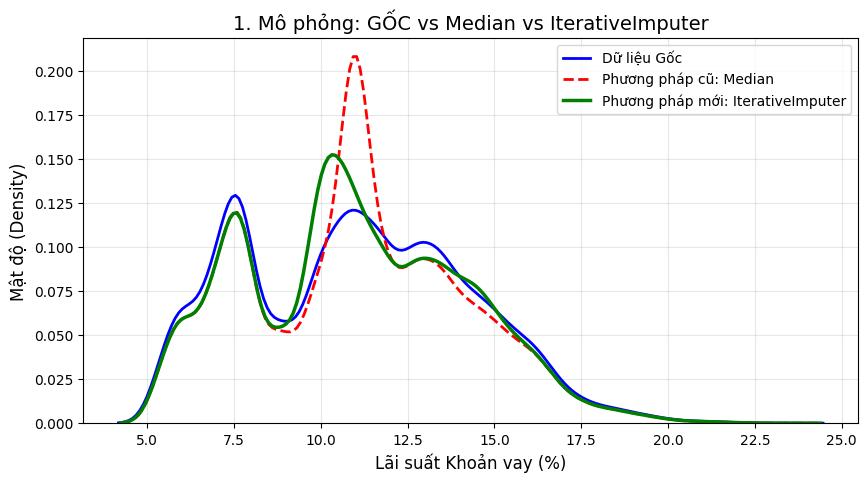

In [4]:
plt.figure(figsize=(10, 5))
sns.kdeplot(original_rate, color='blue', label='Dữ liệu Gốc', linewidth=2)
sns.kdeplot(median_rate, color='red', label='Phương pháp cũ: Median', linestyle='--', linewidth=2)
sns.kdeplot(iter_rate, color='green', label='Phương pháp mới: IterativeImputer', linewidth=2.5)

plt.title('1. Mô phỏng: GỐC vs Median vs IterativeImputer', fontsize=14)
plt.xlabel('Lãi suất Khoản vay (%)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
df_test_gold = pd.read_sql_query("SELECT loan_int_rate FROM gold_credit_risk_test", engine)

preprocessor = joblib.load('preprocessor.pkl')
scaler_gold = preprocessor.named_transformers_['num'].named_steps['scaler']

dummy_matrix_test = np.zeros((len(df_test_gold), 7))
dummy_matrix_test[:, 4] = df_test_gold['loan_int_rate'].values
inversed_test = scaler_gold.inverse_transform(dummy_matrix_test)
test_rate_original_scale = inversed_test[:, 4]

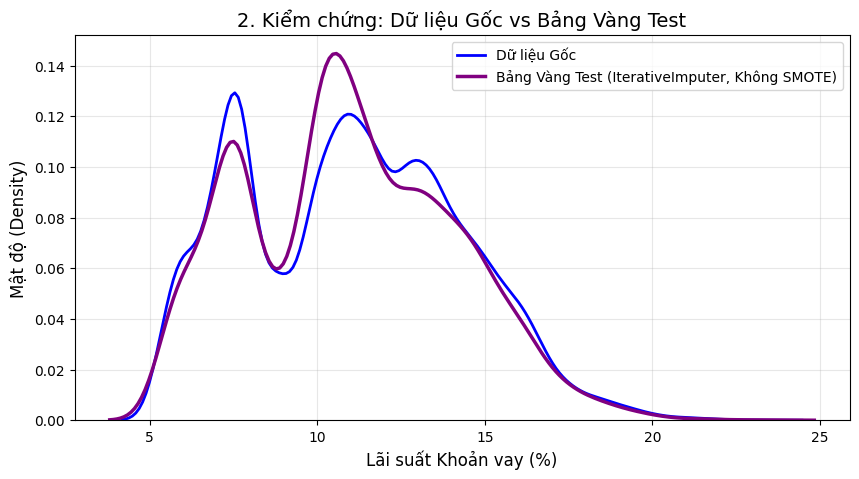

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(original_rate, color='blue', label='Dữ liệu Gốc', linewidth=2)
sns.kdeplot(test_rate_original_scale, color='purple', label='Bảng Vàng Test (IterativeImputer, Không SMOTE)', linestyle='-', linewidth=2.5)

plt.title('2. Kiểm chứng: Dữ liệu Gốc vs Bảng Vàng Test', fontsize=14)
plt.xlabel('Lãi suất Khoản vay (%)', fontsize=12)
plt.ylabel('Mật độ (Density)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()